# Extreme Precipitation: Interannual Mean and IQR (IMERG, GSMaP)

## Purpose
This notebook plots the **interannual mean and interquartile range (IQR)** of the P90/P95 extreme precipitation threshold for the two observational products, IMERG and GSMaP, over an 11-year record (2014-2024) -- long enough for a meaningful
year-to-year spread, unlike the 3-year window the main multi-source notebook's production data uses. No GSRM/model sources are included here; for the multi-source (models + obs) percentile maps, see the companion notebook
`plot_extreme_rain_threshold_map.ipynb`.

## Input Data
6-hourly extreme precipitation percentile thresholds over 2014-2024 (variables `pr_p90`/`pr_p95`, plus the per-calendar-year `pr_annual_p90`/`pr_annual_p95` and their interannual `pr_q25_p*`/`pr_q75_p*`/`pr_iqr_p*`, in mm/h) on a HEALPix zoom 8
grid, one NetCDF file per source. These are separate, longer-period archival files -- not the ones the main notebook reads -- built specifically for this comparison:
```
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip/<source>_precip_percentiles_6h_hp8_v1_2014_2024.nc
```
Generated the same way as the main notebook's files (`waccem/gsrm_cooccurrencefeature/scripts/calc_extreme_precip_thresholds.py`), against an 11-year IMERG store built with `coarsen_healpix.py` (1-hourly -> 6-hourly, same-zoom temporal-only
resample of `/pscratch/sd/w/wcmca1/GPM/healpix/IMERG_V7_1H_zoom8_20010101_20241231.zarr`) and GSMaP's own 2010-2024 6-hourly store (`/pscratch/sd/w/wcmca1/GSMaP/healpix/GSMaPv8_6H_zoom8_20100101_20241231.zarr`) subset to the same 2014-2024
window.

**Sources:** OBS/IMERG (IMERGv7), GSMaP (GSMaPv8) -- both 2014-2024 (11 calendar years).

## Plots Generated
| Figure | Description | Output File |
|--------|-------------|-------------|
| Interannual mean and IQR (P95) | IMERG and GSMaP: the mean of the per-year P95 threshold, its interquartile range across years, and a zonal-mean panel of the same two quantities (shaded band = interannual IQR of the zonal-mean line) | `globalmap_extreme_precip_threshold_P95_obs_interannual.png` |
| Interannual mean and IQR (P90) | Same, for the P90 threshold | `globalmap_extreme_precip_threshold_P90_obs_interannual.png` |

Output figures are saved to: `/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_extremerain_202609/`

## Notes (2026-09-22)
Split out from `plot_extreme_rain_threshold_map.ipynb`, where this figure previously lived, so the interannual analysis can use a longer, more informative record (11 years) independent of whatever period that notebook's own production data
covers (currently 3 years, chosen after comparing the two: the P95 maps and zonal IQR bands differ only slightly between the two periods, but the IQR itself reads as noticeably more meaningful at 11 years -- domain-mean interannual IQR is
about 36-38% larger than at 3 years for both IMERG and GSMaP).

In [1]:
import glob
import numpy as np
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import copy, os
import colormaps as cmaps
import easygems.healpix as egh

In [2]:
# rootdir = '/pscratch/sd/w/wcmca1/hackathon/extreme_precip/'
rootdir = '/global/cfs/cdirs/wcm_shr/hk25/extreme_precip/'

name_map = {
    'obs1': 'IMERGv7',
    'obs2': 'GSMaPv8',
}
name_map_plot = {
    'obs1': 'IMERG',
    'obs2': 'GSMaP',
}
period_suffix = '2014_2024'

# Input filenames: the 11-year archival copies (not the plain _v1.nc files the main notebook reads)
filenames = {key: f"{rootdir}{value}_precip_percentiles_6h_hp8_v1_{period_suffix}.nc" for key, value in name_map.items()}

figdir = '/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_extremerain_202609/'
os.makedirs(figdir, exist_ok=True)
print(figdir)

/global/cfs/cdirs/m1867/zfeng/hk25/figures_cof_extremerain_202609/


### Check if input files exist

In [3]:
for key, value in filenames.items():
    print(f'{value}: {os.path.isfile(value)}')

/global/cfs/cdirs/wcm_shr/hk25/extreme_precip/IMERGv7_precip_percentiles_6h_hp8_v1_2014_2024.nc: True
/global/cfs/cdirs/wcm_shr/hk25/extreme_precip/GSMaPv8_precip_percentiles_6h_hp8_v1_2014_2024.nc: True


## Load IMERG and GSMaP directly

Only two sources, so no `xr.concat`/coordinate-standardization is needed (that machinery in the main notebook exists to combine many sources into one `source`-dimensioned Dataset) -- each file is opened
independently and used with its own `lat` coordinate throughout; the two are never compared cell-by-cell.

In [4]:
datasets = {}
years_dict = {}
for key, filepath in filenames.items():
    print(f"  {key}: {os.path.basename(filepath)}")
    datasets[key] = xr.open_dataset(filepath)
    years_dict[key] = datasets[key].year.values

ds_obs1 = datasets['obs1']
ds_obs2 = datasets['obs2']

year_range = {key: f"{int(np.min(y))}-{int(np.max(y))}" for key, y in years_dict.items()}
print(f"OBS/IMERG ({name_map_plot['obs1']}): {year_range['obs1']}")
print(f"GSMaP ({name_map_plot['obs2']}): {year_range['obs2']}")

  obs1: IMERGv7_precip_percentiles_6h_hp8_v1_2014_2024.nc


  obs2: GSMaPv8_precip_percentiles_6h_hp8_v1_2014_2024.nc
OBS/IMERG (IMERG): 2014-2024
GSMaP (GSMaP): 2014-2024


## Function to plot a grid of maps, with an optional zonal-mean panel

In [5]:
def plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                  min_thresh=None, wspace=None, hspace=None, oob_colors=None,
                  contourf=False, figsize=None, fontsize=None, cb_fontsize=None,
                  show_gridlines=False, figtitle=None, dpi=200, lat_lines=None,
                  zonal_lines=None, zonal_xlabel='Latitude (°)', zonal_ylabel=None, zonal_title=None,
                  zonal_legend_loc='best', zonal_height_ratio=0.85, zonal_width_frac=1.0, zonal_height_frac=1.0):
    """
    Plot a grid of maps with flexible dimensions

    Parameters:
    -----------
    da_list : list of lists
        2D list of xarray DataArrays to plot, dimensions should be [nrow][ncol]
    titles : list of lists
        2D list of titles for each panel, dimensions should be [nrow][ncol]
    levels, colormaps, etc.: can be single values applied to all panels or lists of lists matching da_list
    wspace, hspace : float or None
        Column/row spacing passed straight through to GridSpecFromSubplotSpec, exactly as given -- including whenever a
        zonal panel is present. (Earlier versions silently floored these to 0.12 whenever a zonal panel needed extra
        clearance; that made them impossible to tune below 0.12. Use zonal_width_frac/zonal_height_frac below for
        additional clearance beyond what wspace/hspace alone can give the zonal panel.)
    lat_lines : list or None
        List of latitude values to plot as horizontal lines (e.g., [-20, 20] for tropics)
    zonal_lines : list of dict, or None
        One extra, non-map panel: a zonal-mean line plot, styled like plot_zonal_mean_grid in
        plot_cof_total_rain_seasonal_zonalmean_maps.ipynb (2 degree latitude bins, unweighted mean -- valid since HEALPix
        cells are equal-area -- obs lines thicker than model lines). Each entry is a dict with 'label', 'lat' (1D latitude bin
        centers), 'mean' (1D values), 'color', 'linewidth', and optionally 'q25'/'q75' (1D values): when both are given, a
        shaded band is drawn under the line (the interquartile range of the zonal-mean line's own year-to-year values, not a
        zonal average of a cell-wise interannual spread -- computed by the caller). Placement: if da_list already has an
        empty (None) panel -- an odd number of sources in the grid -- the zonal panel is drawn there; otherwise a new row,
        spanning every column, is appended below the maps.
    zonal_xlabel, zonal_ylabel, zonal_title, zonal_legend_loc : the zonal panel's axis labels, panel title and legend
        location (default 'best': matplotlib places it wherever it best avoids the plotted lines).
    zonal_height_ratio : float
        Height of the appended zonal row relative to one map row (only used when a row is appended, not when an existing
        empty panel is reused). Default 0.85.
    zonal_width_frac, zonal_height_frac : float
        Fraction (0-1] of the zonal panel's own allocated grid width/height its axes actually occupies. width_frac shrinks
        from the LEFT (right edge fixed) -- clearance for the y-axis label/ticks from the panel to its left; height_frac
        shrinks from the TOP (bottom edge fixed, where the x-axis lives) -- clearance above the panel, e.g. from the title
        or the row above it. Both default to 1.0 (no shrink) -- independent, additional levers on top of wspace/hspace,
        for whatever clearance those alone don't give.
    """
    # Get grid dimensions from input data
    nrow = len(da_list)
    ncol = len(da_list[0]) if nrow > 0 else 0

    # Handle case where parameters might be the same for all panels
    def ensure_grid_format(param, param_name):
        if not isinstance(param, list):
            # If single value provided, apply to all panels
            return [[param for _ in range(ncol)] for _ in range(nrow)]
        elif isinstance(param, list):
            if len(param) == 0:
                # Empty list
                return [[[] for _ in range(ncol)] for _ in range(nrow)]
            elif isinstance(param[0], list):
                # Already a list of lists, return as is
                return param
            else:
                # It's a 1D list (like levels=[1,2,3,5,7,10]), use same list for all panels
                return [[param for _ in range(ncol)] for _ in range(nrow)]
        return param

    # Ensure all parameters have proper grid format
    colormaps = ensure_grid_format(colormaps, "colormaps")
    levels = ensure_grid_format(levels, "levels")
    cbticks = ensure_grid_format(cbticks, "cbticks")

    # Where the zonal panel goes: an existing empty (None) map slot (odd number of sources), else a new row spanning every
    # column (even number of sources, the grid is already full)
    zonal_slot = None
    if zonal_lines is not None:
        for r in range(nrow):
            for c in range(ncol):
                if da_list[r][c] is None:
                    zonal_slot = (r, c)
                    break
            if zonal_slot is not None:
                break
    add_zonal_row = zonal_lines is not None and zonal_slot is None

    mpl.rcParams['font.size'] = fontsize
    map_extent = [0, 360, -60, 60]
    proj = ccrs.Robinson(central_longitude=225)
    data_proj = ccrs.PlateCarree()
    resolution = '110m'
    land = cf.NaturalEarthFeature('physical', 'land', resolution)
    ocean = cf.NaturalEarthFeature('physical', 'ocean', resolution)
    borders = cf.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', resolution)

    if add_zonal_row and figsize is not None:
        # Scale the figure height up proportionally so the appended row gets its own share of the canvas
        fig_w, fig_h = figsize
        figsize = (fig_w, fig_h * (nrow + zonal_height_ratio) / nrow)

    fig = plt.figure(figsize=figsize, dpi=100)
    # Setup two columns (left: plots, right: colorbar)
    gs0 = gridspec.GridSpec(1, 2, figure=fig, height_ratios=[1], width_ratios=[1,0.02], wspace=0.05)
    # Setup panels to the left: one extra row when a zonal panel is appended (not when it reuses an empty map slot)
    n_grid_rows = nrow + (1 if add_zonal_row else 0)
    h_ratios = list(np.repeat(1, nrow)) + ([zonal_height_ratio] if add_zonal_row else [])
    w_ratios = list(np.repeat(1, ncol))
    gs = gridspec.GridSpecFromSubplotSpec(n_grid_rows, ncol, subplot_spec=gs0[0],
                                         height_ratios=h_ratios, width_ratios=w_ratios,
                                         wspace=wspace, hspace=hspace)

    def draw_zonal_panel(ax):
        if zonal_width_frac < 1.0 or zonal_height_frac < 1.0:
            pos = ax.get_position()
            new_width = pos.width * zonal_width_frac
            new_height = pos.height * zonal_height_frac
            # width: shrink from the left (right edge fixed) -- clearance for the y-axis label from the panel to its left
            # height: shrink from the top (bottom edge fixed, where the x-axis lives) -- clearance above the panel
            ax.set_position([pos.x0 + (pos.width - new_width), pos.y0, new_width, new_height])
        for zl in zonal_lines:
            color = zl.get('color', 'gray')
            lw = zl.get('linewidth', 1.5)
            lat, mean = zl['lat'], zl['mean']
            ax.plot(lat, mean, color=color, linewidth=lw, label=zl['label'])
            if zl.get('q25') is not None and zl.get('q75') is not None:
                ax.fill_between(lat, zl['q25'], zl['q75'], color=color, alpha=0.2, linewidth=0)
        if zonal_title:
            ax.set_title(zonal_title, fontsize=fontsize, fontweight='bold', loc='left')
        ax.set_xlabel(zonal_xlabel, fontsize=fontsize)
        if zonal_ylabel:
            ax.set_ylabel(zonal_ylabel, fontsize=fontsize)
        ax.tick_params(axis='both', labelsize=max(fontsize * 0.8, 8))
        ax.grid(True, alpha=0.7, linestyle=':')
        ax.legend(loc=zonal_legend_loc, framealpha=0.9, fontsize=max(fontsize * 0.6, 8))

    # Loop over each panel in the grid
    cf1 = None  # Will store the last plot for colorbar
    for row in range(nrow):
        for col in range(ncol):
            # Get panel index
            panel_idx = row * ncol + col

            # Get data for this panel
            Var = da_list[row][col]
            if Var is not None:

                # Create subplot
                ax = plt.subplot(gs[panel_idx], projection=proj)
                ax.set_global()
                ax.add_feature(land, facecolor='none', edgecolor='k', zorder=3)
                ax.set_aspect('auto', adjustable=None)

                # Add title
                flabel = ax.text(0.02, 0.94, titles[row][col], transform=ax.transAxes, fontsize=fontsize)
                flabel.set_bbox(dict(facecolor='w', alpha=0.8, edgecolor='w'))

                # Apply minimum threshold if provided
                if min_thresh is not None:
                    Var = Var.where(Var > min_thresh)

                # Setup colormap
                cmap = copy.copy(mpl.colormaps.get_cmap(colormaps[row][col]))

                # Set out-of-bounds colors
                if oob_colors is not None:
                    oob_c = oob_colors
                    if oob_c is not None:
                        cmap.set_over(oob_c['over'])
                        cmap.set_under(oob_c['under'])

                # Create color normalization
                norm = colors.BoundaryNorm(boundaries=levels[row][col], ncolors=cmap.N)

                # Plot data
                if not contourf:
                    cf1 = egh.healpix_show(Var, ax=ax, cmap=cmap, norm=norm, zorder=2)
                else:
                    cf1 = egh.healpix_contour(Var, ax=ax, norm=norm, cmap=cmap, transform=data_proj, zorder=2)

                # Add gridlines
                if show_gridlines:
                    gl = ax.gridlines(crs=data_proj, draw_labels=False, linestyle='--', linewidth=0.5, zorder=10)

                # Add latitude lines if specified
                if lat_lines is not None:
                    for lat in lat_lines:
                        # Create longitude array spanning the globe
                        lons = np.linspace(-180, 180, 361)
                        lats = np.full_like(lons, lat)
                        ax.plot(lons, lats, color='k', linestyle='--', linewidth=1.5,
                            transform=data_proj, zorder=4, alpha=0.8)
            elif zonal_slot == (row, col):
                ax_zonal = plt.subplot(gs[panel_idx])
                draw_zonal_panel(ax_zonal)

    if add_zonal_row:
        ax_zonal = fig.add_subplot(gs[nrow, :])
        draw_zonal_panel(ax_zonal)

    # Add colorbar (using the last plotted data)
    if cf1 is not None:
        cax = plt.subplot(gs0[1])
        cbar = plt.colorbar(cf1, cax=cax, label=cblabels, ticks=cbticks[row][col],
                           orientation='vertical', extend='both')

    # Add suptitle
    if figtitle:
        fig.suptitle(figtitle, y=0.92, fontweight='bold')

    # Save figure
    fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
    return fig

In [6]:
def compute_zonal_mean(da, lat_bins):
    """
    Zonal mean of a HEALPix DataArray (dim 'cell', with a 'lat' coordinate on it): the unweighted mean over the cells in
    each latitude bin, valid because HEALPix cells are equal-area by construction. Preserves any other dimension da has
    (e.g. 'year'). Adapted from compute_seasonal_zonal_mean in plot_cof_total_rain_seasonal_zonalmean_maps.ipynb, without
    its 'season' dimension. (Same helper as in the main notebook, duplicated here per this repo's existing per-notebook
    convention.)

    Parameters:
    -----------
    da : xarray.DataArray
        Values on the 'cell' dimension, with a 'lat' coordinate on that dimension.
    lat_bins : array-like
        Latitude bin edges.

    Returns:
    --------
    xarray.DataArray with 'cell' replaced by 'latitude' (bin centers).
    """
    lat_bins = np.asarray(lat_bins)
    lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
    result = da.groupby_bins('lat', bins=lat_bins).mean(dim='cell')
    result = result.rename({'lat_bins': 'latitude'}).assign_coords(latitude=lat_centers)
    return result


# 2-degree latitude bins over the full globe, matching the main notebook
lat_bins = np.arange(-90, 91, 2)

# Both sources drawn the same way (thick, dark lines) -- there's no model/obs distinction to set apart here
source_colors = {
    'obs1': 'black',
    'obs2': 'dimgray',
}
source_linewidths = {
    'obs1': 3.0,
    'obs2': 3.0,
}

## Interannual Mean and IQR of the P95 Threshold

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1650: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


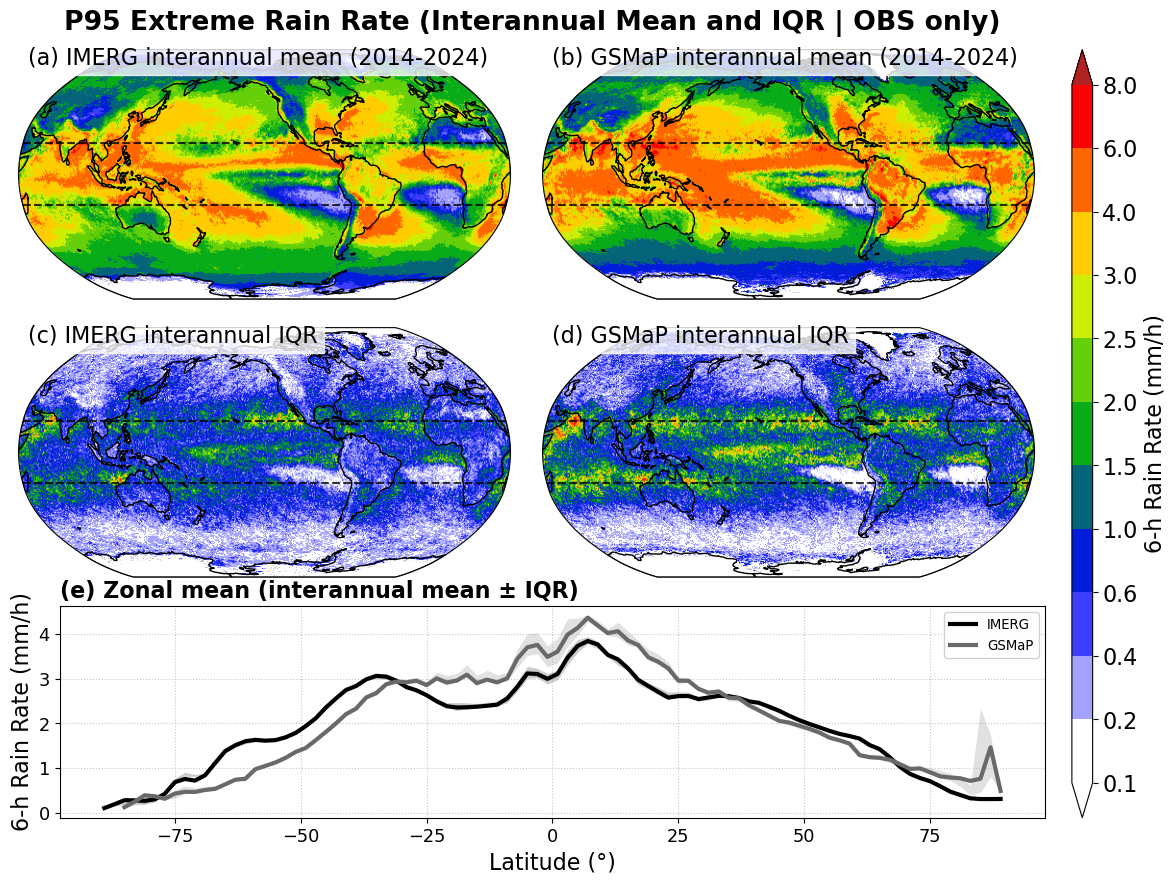

In [7]:
tropics_lat = [-20, 20]
extreme_percentile = 'p95'
VAR = f'pr_{extreme_percentile}'
annual_var = f'pr_annual_{extreme_percentile}'
iqr_var = f'pr_iqr_{extreme_percentile}'

# Interannual mean and IQR of the P95 threshold, for the two observational products (IMERG, GSMaP) -- both always
# have annual/IQR data here (11 qualifying years each), unlike the main multi-source notebook where production's IMERG
# file may not carry these variables -- so no guard is needed
mean_obs1 = ds_obs1[annual_var].mean(dim='year')
mean_obs2 = ds_obs2[annual_var].mean(dim='year')
iqr_obs1 = ds_obs1[iqr_var]
iqr_obs2 = ds_obs2[iqr_var]

da_list = [
    [mean_obs1, mean_obs2],
    [iqr_obs1, iqr_obs2],
]
titles = [
    [f"(a) {name_map_plot['obs1']} interannual mean ({year_range['obs1']})", f"(b) {name_map_plot['obs2']} interannual mean ({year_range['obs2']})"],
    [f"(c) {name_map_plot['obs1']} interannual IQR", f"(d) {name_map_plot['obs2']} interannual IQR"],
]

# Setup grid parameters (same style as the main notebook's maps)
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 16
cb_fontsize = 10
wspace = 0.02
hspace = 0.12
varname1 = '6-h Rain Rate'
units = 'mm/h'
figtitle = f'{extreme_percentile.upper()} Extreme Rain Rate (Interannual Mean and IQR | OBS only)'
lat_lines = tropics_lat

# Same levels/colormap as the main notebook's maps: one shared colorbar for the whole figure, so the mean and IQR rows
# must use one color scale -- the IQR values are smaller, so that row reads mostly in the lower colors, the same
# trade-off the 1-hourly notebook's own P95/IQR figure makes
levels = [0.1,0.2,0.4,0.6,1,1.5,2,2.5,3,4,6,8]
min_thresh = None
colormaps = cmaps.WhBlGrYeRe
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_extreme_precip_threshold_{extreme_percentile.upper()}_obs_interannual.png'

# Zonal-mean panel: the zonal profile of the interannual-mean row's two sources (the row that represents "the extreme
# threshold"; the IQR row is itself a spread measure, so it is not also shown zonally), with a shaded band = the
# interquartile range, across years, of the zonally-averaged annual value itself (not a zonal average of the cell-wise
# pr_q25/pr_q75, which would understate the spread of the line since spatial averaging within a band already damps
# per-cell noise before any quantile is taken)
zonal_lines = []
for key, ds_src, mean_da in (('obs1', ds_obs1, mean_obs1), ('obs2', ds_obs2, mean_obs2)):
    zmean = compute_zonal_mean(mean_da, lat_bins)
    zonal_annual = compute_zonal_mean(ds_src[annual_var], lat_bins)
    zonal_lines.append({'label': name_map_plot[key], 'lat': zmean['latitude'].values, 'mean': zmean.values,
                        'q25': zonal_annual.quantile(0.25, dim='year').values, 'q75': zonal_annual.quantile(0.75, dim='year').values,
                        'color': source_colors[key], 'linewidth': source_linewidths[key]})

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200,
                    zonal_lines=zonal_lines, zonal_title='(e) Zonal mean (interannual mean ± IQR)',
                    zonal_ylabel=f'{varname1} ({units})', zonal_legend_loc='best', zonal_width_frac=0.95)

## Interannual Mean and IQR of the P90 Threshold

/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1650: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


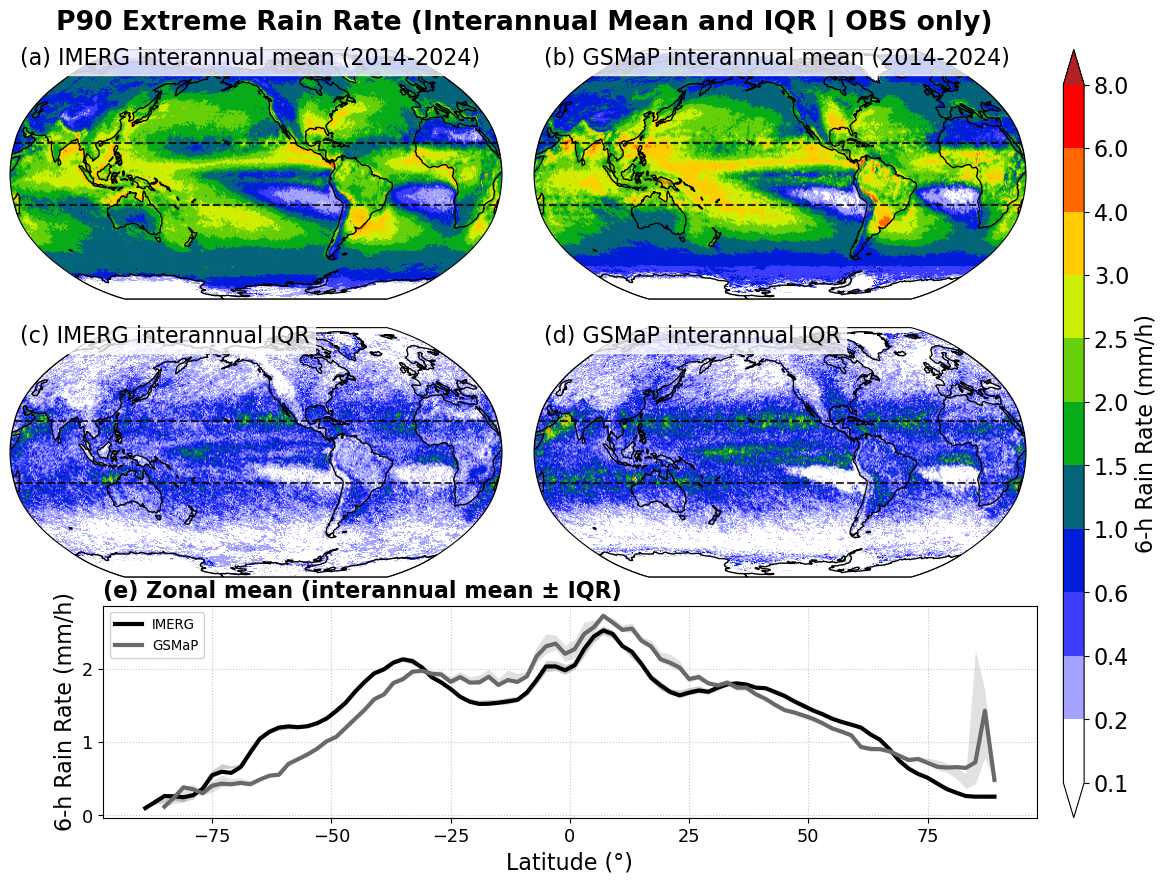

In [8]:
tropics_lat = [-20, 20]
extreme_percentile = 'p90'
VAR = f'pr_{extreme_percentile}'
annual_var = f'pr_annual_{extreme_percentile}'
iqr_var = f'pr_iqr_{extreme_percentile}'

# Interannual mean and IQR of the P90 threshold, for the two observational products (IMERG, GSMaP) -- both always
# have annual/IQR data here (11 qualifying years each), unlike the main multi-source notebook where production's IMERG
# file may not carry these variables -- so no guard is needed
mean_obs1 = ds_obs1[annual_var].mean(dim='year')
mean_obs2 = ds_obs2[annual_var].mean(dim='year')
iqr_obs1 = ds_obs1[iqr_var]
iqr_obs2 = ds_obs2[iqr_var]

da_list = [
    [mean_obs1, mean_obs2],
    [iqr_obs1, iqr_obs2],
]
titles = [
    [f"(a) {name_map_plot['obs1']} interannual mean ({year_range['obs1']})", f"(b) {name_map_plot['obs2']} interannual mean ({year_range['obs2']})"],
    [f"(c) {name_map_plot['obs1']} interannual IQR", f"(d) {name_map_plot['obs2']} interannual IQR"],
]

# Setup grid parameters (same style as the main notebook's maps)
nrow = len(da_list)
ncol = len(da_list[0]) if nrow > 0 else 1
figwidth = 14
height_ratio_per_panel = 0.5
figheight = nrow * (figwidth / ncol) * height_ratio_per_panel
figsize = [figwidth, figheight]
fontsize = 16
cb_fontsize = 10
wspace = 0.02
hspace = 0.12
varname1 = '6-h Rain Rate'
units = 'mm/h'
figtitle = f'{extreme_percentile.upper()} Extreme Rain Rate (Interannual Mean and IQR | OBS only)'
lat_lines = tropics_lat

# Same levels/colormap as the main notebook's maps: one shared colorbar for the whole figure, so the mean and IQR rows
# must use one color scale -- the IQR values are smaller, so that row reads mostly in the lower colors, the same
# trade-off the 1-hourly notebook's own P95/IQR figure makes
levels = [0.1,0.2,0.4,0.6,1,1.5,2,2.5,3,4,6,8]
min_thresh = None
colormaps = cmaps.WhBlGrYeRe
cbticks = levels
oob_colors = {'over':'firebrick', 'under':'white'}
cblabels = f'{varname1} ({units})'
figname = f'{figdir}globalmap_extreme_precip_threshold_{extreme_percentile.upper()}_obs_interannual.png'

# Zonal-mean panel: the zonal profile of the interannual-mean row's two sources (the row that represents "the extreme
# threshold"; the IQR row is itself a spread measure, so it is not also shown zonally), with a shaded band = the
# interquartile range, across years, of the zonally-averaged annual value itself (not a zonal average of the cell-wise
# pr_q25/pr_q75, which would understate the spread of the line since spatial averaging within a band already damps
# per-cell noise before any quantile is taken)
zonal_lines = []
for key, ds_src, mean_da in (('obs1', ds_obs1, mean_obs1), ('obs2', ds_obs2, mean_obs2)):
    zmean = compute_zonal_mean(mean_da, lat_bins)
    zonal_annual = compute_zonal_mean(ds_src[annual_var], lat_bins)
    zonal_lines.append({'label': name_map_plot[key], 'lat': zmean['latitude'].values, 'mean': zmean.values,
                        'q25': zonal_annual.quantile(0.25, dim='year').values, 'q75': zonal_annual.quantile(0.75, dim='year').values,
                        'color': source_colors[key], 'linewidth': source_linewidths[key]})

# Plot figure
fig = plot_maps_grid(da_list, titles, levels, colormaps, cblabels, cbticks, figname,
                    figtitle=figtitle, lat_lines=lat_lines,
                    min_thresh=min_thresh, wspace=wspace, hspace=hspace, figsize=figsize,
                    fontsize=fontsize, cb_fontsize=cb_fontsize, contourf=False,
                    oob_colors=oob_colors, show_gridlines=False, dpi=200,
                    zonal_lines=zonal_lines, zonal_title='(e) Zonal mean (interannual mean ± IQR)',
                    zonal_ylabel=f'{varname1} ({units})', zonal_legend_loc='best', zonal_width_frac=0.9)